# MNIST Denoising Autoencoder via NumPy
An implementation of a denoising autoencoder built entirely from scratch with NumPy.
We load the MNIST data with scikit-learn or a fast mirror, introduce synthetic noise, train using a custom-coded Adam optimizer, and inspect the resulting reconstruction quality.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import urllib.request
import os

print("Loading MNIST dataset...")
try:
    # Attempting to load from a high-speed mirror first
    url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"
    local_path = "mnist.npz"
    if not os.path.exists(local_path):
        print("Downloading dataset from Google APIs mirror...")
        urllib.request.urlretrieve(url, local_path)

    with np.load(local_path) as data:
        train_x = data['x_train']
        test_x = data['x_test']

    # Combine training and test datasets to replicate fetch_openml structure
    combined = np.concatenate([train_x, test_x], axis=0)
    pixel_data = combined.reshape(combined.shape[0], -1) / 255.0
    print("Dataset successfully loaded from local cache/mirror.")
except Exception as e:
    print(f"Fallback to fetch_openml due to error: {e}")
    from sklearn.datasets import fetch_openml
    # Retrieve MNIST from OpenML (parser set to liac-arff to ensure compatibility)
    mnist_dataset = fetch_openml('mnist_784', version=1, as_frame=False, parser='liac-arff')
    pixel_data = mnist_dataset.data / 255.0

# Restrict the size to 20,000 images to ensure quick training runs
pixel_data = pixel_data[:20000]
train_imgs, test_imgs = train_test_split(pixel_data, test_size=0.1, random_state=42)

print(f"Number of training examples: {train_imgs.shape[0]}")
print(f"Number of testing examples: {test_imgs.shape[0]}")


Loading MNIST dataset...


Dataset successfully loaded from local cache/mirror.
Number of training examples: 18000
Number of testing examples: 2000


## 2. Inject Synthetic Noise
We overlay Gaussian noise on the clean images, making sure to clip the pixel range back to [0, 1].

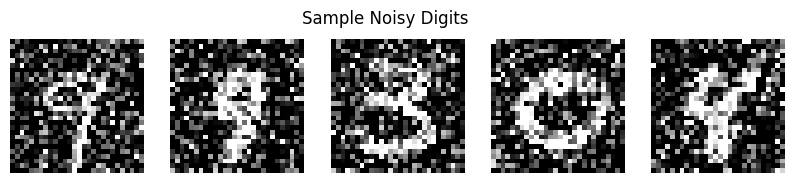

In [ ]:
noise_level = 0.5
noisy_train_imgs = train_imgs + noise_level * np.random.randn(*train_imgs.shape)
noisy_test_imgs = test_imgs + noise_level * np.random.randn(*test_imgs.shape)
noisy_train_imgs = np.clip(noisy_train_imgs, 0.0, 1.0)
noisy_test_imgs = np.clip(noisy_test_imgs, 0.0, 1.0)

# Display a few noisy inputs to see the effect
plt.figure(figsize=(10, 2))
for idx in range(5):
    plot_axis = plt.subplot(1, 5, idx + 1)
    plt.imshow(noisy_train_imgs[idx].reshape(28, 28), cmap='gray')
    plot_axis.axis('off')
plt.suptitle("Sample Noisy Digits")
plt.show()


## 3. Network Architecture and Optimization Configuration
We define a simple feedforward autoencoder with a single hidden layer (784 dimensions reduced to 128, then reconstructed back to 784) and configure a custom Adam optimizer.

In [ ]:
# Setup neural net dimensions and optimization hyperparameters
dim_input = 784
dim_hidden = 128
dim_output = 784
alpha_lr = 0.005
max_epochs = 30
size_batch = 128

# Standard weight initialization (He style)
weights_1 = np.random.randn(dim_input, dim_hidden) * np.sqrt(2.0 / dim_input)
bias_1 = np.zeros(dim_hidden)
weights_2 = np.random.randn(dim_hidden, dim_output) * np.sqrt(2.0 / dim_hidden)
bias_2 = np.zeros(dim_output)

# Define math functions for activations and derivatives
def rectified_linear(val):
    return np.maximum(0, val)

def rectified_linear_derivative(val):
    return (val > 0).astype(float)

def logistic_sigmoid(val):
    return 1.0 / (1.0 + np.exp(-np.clip(val, -500, 500)))

def logistic_sigmoid_derivative(val):
    activated = logistic_sigmoid(val)
    return activated * (1.0 - activated)

# Track running moments for Adam updates
first_moment_w1, second_moment_w1 = np.zeros_like(weights_1), np.zeros_like(weights_1)
first_moment_b1, second_moment_b1 = np.zeros_like(bias_1), np.zeros_like(bias_1)
first_moment_w2, second_moment_w2 = np.zeros_like(weights_2), np.zeros_like(weights_2)
first_moment_b2, second_moment_b2 = np.zeros_like(bias_2), np.zeros_like(bias_2)

decay_rate_1, decay_rate_2, stability_eps = 0.9, 0.999, 1e-8
time_step = 0


## 4. Optimization Loop
Train the parameters using custom backpropagation and parameter updates via the Adam optimizer.

Beginning parameter training utilizing Adam algorithm...


Epoch 01/30, Loss: 0.0557


Epoch 05/30, Loss: 0.0208


Epoch 10/30, Loss: 0.0192


Epoch 15/30, Loss: 0.0188


Epoch 20/30, Loss: 0.0186


Epoch 25/30, Loss: 0.0183


Epoch 30/30, Loss: 0.0183


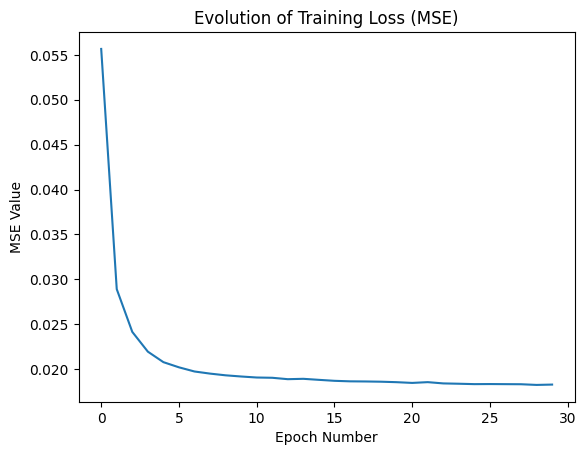

In [ ]:
total_train_size = train_imgs.shape[0]
recorded_losses = []

print("Beginning parameter training utilizing Adam algorithm...")
for current_epoch in range(max_epochs):
    shuffled_order = np.arange(total_train_size)
    np.random.shuffle(shuffled_order)

    accumulated_loss = 0.0
    for offset in range(0, total_train_size, size_batch):
        batch_indices = shuffled_order[offset:offset + size_batch]
        batch_inputs = noisy_train_imgs[batch_indices]
        batch_targets = train_imgs[batch_indices]

        # Step 1: Forward calculation
        linear_activation_1 = batch_inputs.dot(weights_1) + bias_1
        post_activation_1 = rectified_linear(linear_activation_1)
        linear_activation_2 = post_activation_1.dot(weights_2) + bias_2
        reconstructed_batch = logistic_sigmoid(linear_activation_2)

        # Step 2: Calculate Mean Squared Error
        current_mse = np.mean((reconstructed_batch - batch_targets) ** 2)
        accumulated_loss += current_mse * len(batch_indices)

        # Step 3: Backward pass (compute gradients)
        grad_reconstructed = 2.0 * (reconstructed_batch - batch_targets) / len(batch_indices)
        grad_linear_2 = grad_reconstructed * logistic_sigmoid_derivative(linear_activation_2)
        grad_weights_2 = post_activation_1.T.dot(grad_linear_2)
        grad_bias_2 = np.sum(grad_linear_2, axis=0)

        grad_post_activation_1 = grad_linear_2.dot(weights_2.T)
        grad_linear_1 = grad_post_activation_1 * rectified_linear_derivative(linear_activation_1)
        grad_weights_1 = batch_inputs.T.dot(grad_linear_1)
        grad_bias_1 = np.sum(grad_linear_1, axis=0)

        # Step 4: Apply Adam parameter updates
        time_step += 1
        for parameter, gradient, moment1, moment2 in zip(
            [weights_1, bias_1, weights_2, bias_2],
            [grad_weights_1, grad_bias_1, grad_weights_2, grad_bias_2],
            [first_moment_w1, first_moment_b1, first_moment_w2, first_moment_b2],
            [second_moment_w1, second_moment_b1, second_moment_w2, second_moment_b2]
        ):
            moment1[:] = decay_rate_1 * moment1 + (1.0 - decay_rate_1) * gradient
            moment2[:] = decay_rate_2 * moment2 + (1.0 - decay_rate_2) * (gradient ** 2)
            corrected_moment1 = moment1 / (1.0 - decay_rate_1 ** time_step)
            corrected_moment2 = moment2 / (1.0 - decay_rate_2 ** time_step)
            parameter -= alpha_lr * corrected_moment1 / (np.sqrt(corrected_moment2) + stability_eps)

    epoch_mean_loss = accumulated_loss / total_train_size
    recorded_losses.append(epoch_mean_loss)
    if (current_epoch + 1) % 5 == 0 or current_epoch == 0:
        print(f"Epoch {current_epoch+1:02d}/{max_epochs}, Loss: {epoch_mean_loss:.4f}")

plt.plot(recorded_losses)
plt.title("Evolution of Training Loss (MSE)")
plt.xlabel("Epoch Number")
plt.ylabel("MSE Value")
plt.show()


## 5. Model Inference and Visual Comparison
Pass the corrupted test images through the autoencoder to denoise them and present side-by-side comparison displays.

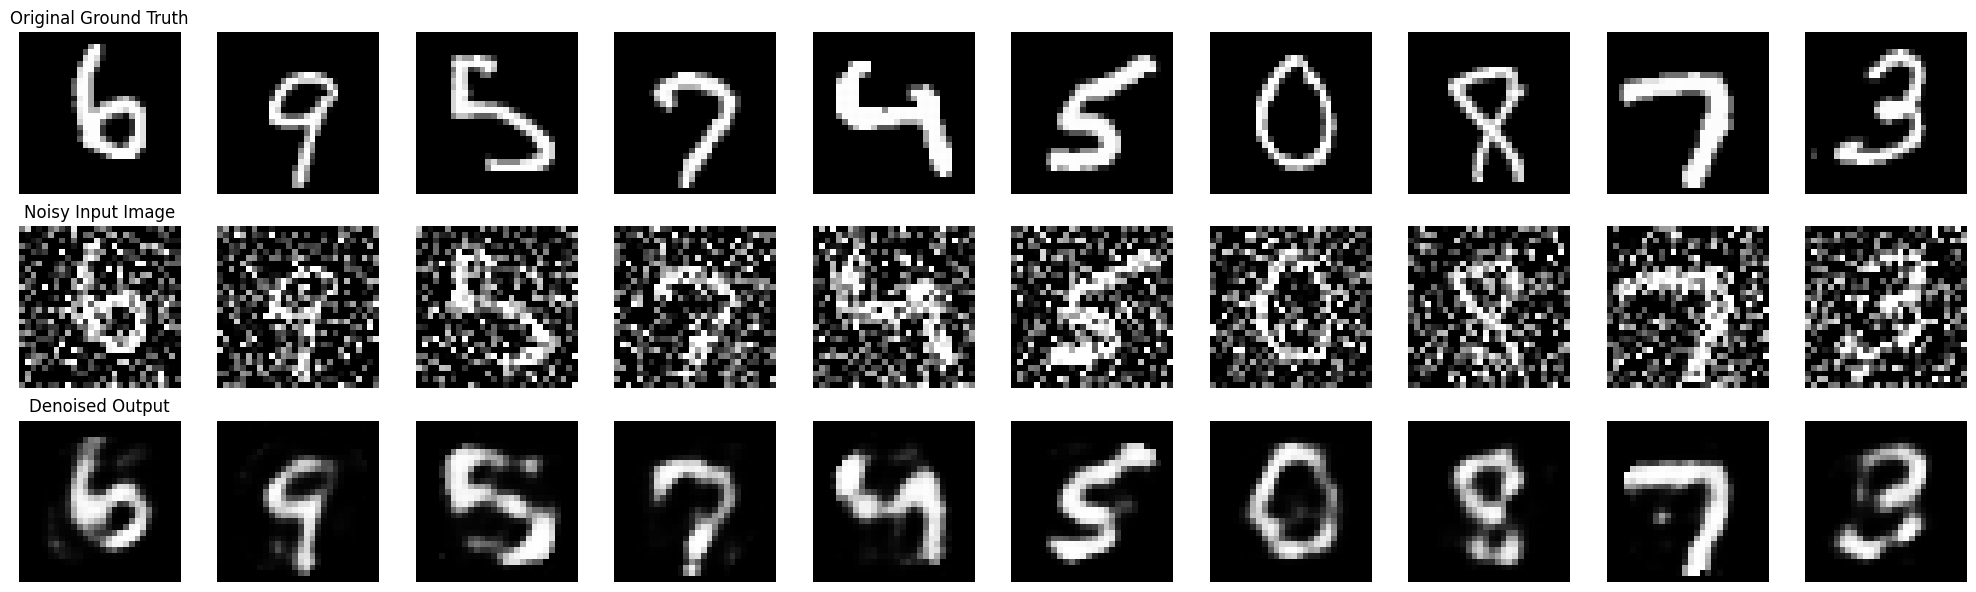

In [ ]:
# Compute network predictions for the test dataset
test_linear_1 = noisy_test_imgs.dot(weights_1) + bias_1
test_activation_1 = rectified_linear(test_linear_1)
test_linear_2 = test_activation_1.dot(weights_2) + bias_2
test_denoised_output = logistic_sigmoid(test_linear_2)

# Set up visualization grid comparing raw, noisy, and denoised images
num_display = 10
plt.figure(figsize=(20, 6))
for display_idx in range(num_display):
    # Render targets (uncorrupted)
    plot_ax = plt.subplot(3, num_display, display_idx + 1)
    plt.imshow(test_imgs[display_idx].reshape(28, 28), cmap='gray')
    plot_ax.axis('off')
    if display_idx == 0:
        plt.title("Original Ground Truth")

    # Render noisy inputs
    plot_ax = plt.subplot(3, num_display, display_idx + 1 + num_display)
    plt.imshow(noisy_test_imgs[display_idx].reshape(28, 28), cmap='gray')
    plot_ax.axis('off')
    if display_idx == 0:
        plt.title("Noisy Input Image")

    # Render denoised outputs
    plot_ax = plt.subplot(3, num_display, display_idx + 1 + 2 * num_display)
    plt.imshow(test_denoised_output[display_idx].reshape(28, 28), cmap='gray')
    plot_ax.axis('off')
    if display_idx == 0:
        plt.title("Denoised Output")

plt.tight_layout()
plt.show()
